In [15]:
import random
from datasketch import MinHash
import statistics
import numpy as np


In [29]:
words = ['Lorem', 'Ipsum', 'has', 'been', 'the', "industry's", 'standard', 'dummy', 'text', 'ever', 
         'since', 'the', '1500s,', 'when', 'an', 'unknown', 'printer', 'took', 'a', 'galley', 'of', 
         'type', 'and', 'scrambled', 'it', 'to', 'make', 'a', 'type', 'specimen', 'book']


In [30]:
data = []

for e in range(1000):
    r = random.choices(words, k= 30 + random.randint(0, 5))
    l = random.choices(words, k= 30 + random.randint(0, 5))
    
    data.append([r,l])
    

In [45]:
errors = []
jaccard = []

for p in data:
    m1, m2 = MinHash(), MinHash()
    
    data1 = p[0]
    data2 = p[1]
    
    
    for d in data1:
        m1.update(d.encode('utf8'))
    for d in data2:
        m2.update(d.encode('utf8'))
        
    s1 = set(data1)
    s2 = set(data2)
    actual_jaccard = float(len(s1.intersection(s2)))/float(len(s1.union(s2)))
    jaccard .append( m1.jaccard(m2))
        
    errors.append(abs(m1.jaccard(m2) - actual_jaccard) )


In [32]:
mean_errors = statistics.mean(errors)

In [33]:
print(mean_errors)

0.03706789109078797


In [41]:
import json

with open('accuraccy_data.json', 'w') as outfile:
    json.dump( {'datum': data}, outfile)

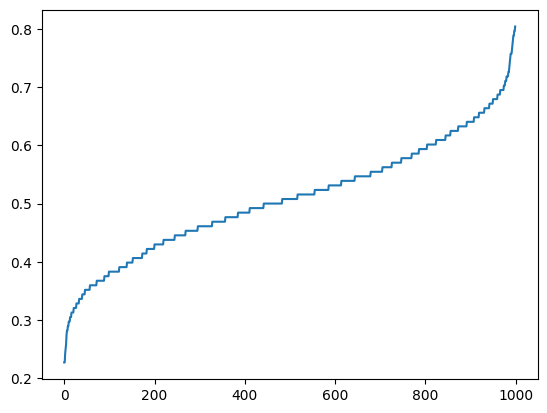

In [48]:
import matplotlib.pyplot as plt

plt.plot(sorted(jaccard))
plt.show()

In [1]:
from datasketch import MinHashLSHForest, MinHash

data1 = ['minhash', 'is', 'a', 'probabilistic', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'datasets']
data2 = ['minhash', 'is', 'a', 'probability', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'documents']
data3 = ['minhash', 'is', 'probability', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'documents']

# Create MinHash objects
m1 = MinHash(num_perm=128)
m2 = MinHash(num_perm=128)
m3 = MinHash(num_perm=128)
for d in data1:
    m1.update(d.encode('utf8'))
for d in data2:
    m2.update(d.encode('utf8'))
for d in data3:
    m3.update(d.encode('utf8'))

# Create a MinHash LSH Forest with the same num_perm parameter
forest = MinHashLSHForest(num_perm=128)

# Add m2 and m3 into the index
forest.add("m2", m2)
forest.add("m3", m3)

# IMPORTANT: must call index() otherwise the keys won't be searchable
forest.index()

# Check for membership using the key
print("m2" in forest)
print("m3" in forest)

# Using m1 as the query, retrieve top 2 keys that have the higest Jaccard
result = forest.query(m1, 2)
print("Top 2 candidates", result)

True
True
Top 2 candidates ['m2', 'm3']


In [7]:
forest._H(np.array([3,4]))


b'\x00\x00\x00\x00\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00\x04'

In [19]:
print(np.array([323489234723,44892037490823894], dtype=np.uint64))
print(np.array([323489234723,44892037490823894],dtype=np.uint64).byteswap())

print(bytes(np.array([323489234723,44892037490823894],dtype=np.uint64)))
x = bytes(np.array([323489234723,44892037490823894],dtype=np.uint64).byteswap().data)

x[:2]


[     323489234723 44892037490823894]
[ 2593920902399787008 15443655640164966144]
b'#\xffuQK\x00\x00\x00\xd6R\xe2\xfb\x11}\x9f\x00'


b'\x00\x00'

In [12]:
from datasketch import MinHashLSHForest, MinHash
from time import time

start = time()

data1 = ['minhash', 'is', 'a', 'probabilistic', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'datasets','ut', 'incidunt', 'facilis', 'id', 'consequatur', 'assumenda', 'sed', 'ut', 'pariatur', 'suscipit', 'omnis', 'ratione', 'iure', 'fuga', 'ut', 'quibusdam', 'itaque', 'minus', 'rem', 'est' ]

for _ in range(40000):
    m1 = MinHash(num_perm=128)
    for d in data1:
        m1.update(d.encode('utf8'))


end = time()

print(end-start)

23.632458209991455


In [13]:
from datasketch import MinHashLSHForest, MinHash
from time import time

start = time()

data1 = ['minhash', 'is', 'a', 'probabilistic', 'data', 'structure', 'for',
        'estimating', 'the', 'similarity', 'between', 'datasets','ut', 'incidunt', 'facilis', 'id', 'consequatur', 'assumenda', 'sed', 'ut', 'pariatur', 'suscipit', 'omnis', 'ratione', 'iure', 'fuga', 'ut', 'quibusdam', 'itaque', 'minus', 'rem', 'est' ]

for _ in range(40000):
    m1 = MinHash(num_perm=128)
    m1.update_batch([s.encode('utf-8') for s in data1])


end = time()

print(end-start)

19.183876037597656
